In [1]:
from IPython.display import SVG, display

import os
import MDAnalysis as md
import shaker

main_dir = os.getcwd()

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Basic Molecule Parameterization with `Shaker`

This tutorial demonstrates a simple workflow for parameterizing a molecule using `Shaker`.

You will learn how to **(1) map an atomistic (AA) molecule to a coarse-grained (CG) representation**, **(2) visualize and verify the resulting CG mapping**, **(3) obtain initial guesses for bonded parameters**, **(4) set up a simple CG simulation**, and **(5) iteratively refine the bonded parameters**.

This tutorial assumes a basic familiarity with **coarse-grained model parameterization**, particularly within the Martini framework.

In [2]:
author  = 'Luis Borges-Araujo'

itp_header = [
    f"; Parameterised by {author} @ ENS de Lyon, 2026.\n"
    "; Molecular name: \n",
    "; SMILES: \n",
]

## AA reference sims (already PBC treated and removed solvent.)
GRO = '../AA_references/BasicParam/AA.pdb'
XTC = '../AA_references/BasicParam/AA.xtc'

### 1. Define mapping & map AA to CG

The first step in any parameterization workflow is defining the **mapping** between the atomistic (AA) representation and the coarse-grained (CG) model.

This can be conveniently done using [cgbuilder](https://lp0lp.github.io/cgbuilder/), which allows you to interactively group AA atoms into CG beads and export the resulting mapping in the **`Shaker` format**.

At this stage, you will also define **bead names** and assign provisional **CG bead types**. These bead types are only an initial guess and can be further refined later by comparing the molecule’s **partitioning behavior** with available experimental or theoretical data.

Once the mapping is defined, `shaker.mapper.map_aa2cg` can be used to generate a **CG-mapped trajectory** from the reference AA simulation. This mapped trajectory serves as the reference from which the bonded parameters will be derived.

To visually confirm that the mapping is correct, `Shaker` provides two rendering utilities:

* `shaker.render.render_2dMapping` to visualize the atom-to-bead assignment in 2D
* `shaker.render.render_mapping` to inspect the mapping directly on the 3D structure

In [3]:
resname='MOL'
A   = ['Cl1','Cl1','C0B','C0B','C0A','C05']
B   = ['C06','C06','C05','C08','Cl0','Cl0']
C   = ['C09','C09','C08','H0V','H0W','H0W','C0A','H0X']
D   = ['O04','C03','N02','H0U']
E   = ['C00','C0D','C0D','C0E','H0Y','H0Y']
F   = ['C0E','N0F','N0F','C0G']
G   = ['C01','C01','H0T','H0T','C00','C0G',]
H   = ['N0H','H0S','C0I','O0J',]
I   = ['H0Q','H0R','C0K','C0M','C0M','H0N','H0O','H0P',]

bead_assignments = [A,       B,     C,     D,     E,       F,     G,     H,     I]
bead_types       = [ 'SX3', 'SX3', 'TC5', 'SP2', 'TC5', 'TN6a', 'TC5', 'SP2', 'TC1']
bead_names       = [  'R1',  'R2',  'R3',  'P1',  'R4',   'R5',  'R6',  'P2',  'C1']
bead_charges     = [     0,     0,     0,     0,     0,      0,     0,     0,    0]

shaker.mapper.map_aa2cg(GRO, XTC,
                        [resname,], [bead_assignments,], [bead_names,],)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/gitbuilds/Shaker/shaker/mapper.py:110: DuplicateWarning: AtomGroup.center_of_geometry(): 'ag' <AtomGroup with 6 atoms> contains duplicates. Results might be biased!
  coords[k] = ag.center_of_geometry()
/local/lborge01/gitbuilds/Shaker/shaker/mapper.py:110: DuplicateWarning: AtomGroup.center_of_geometry(): 'ag' <AtomGroup with 8 atoms> contains duplicates. Results might be biased!
  coords[k] = ag.center_of_geometry()
/local/lborge01/gitbuilds/Shaker/shaker/mapper.py:110: DuplicateWarning: AtomGroup.center_of_geometry(): 'ag' <AtomGroup with 4 atoms> contains duplicates. Results might be biased!
  coords[k] = ag.center_of_geometry()
/local/l

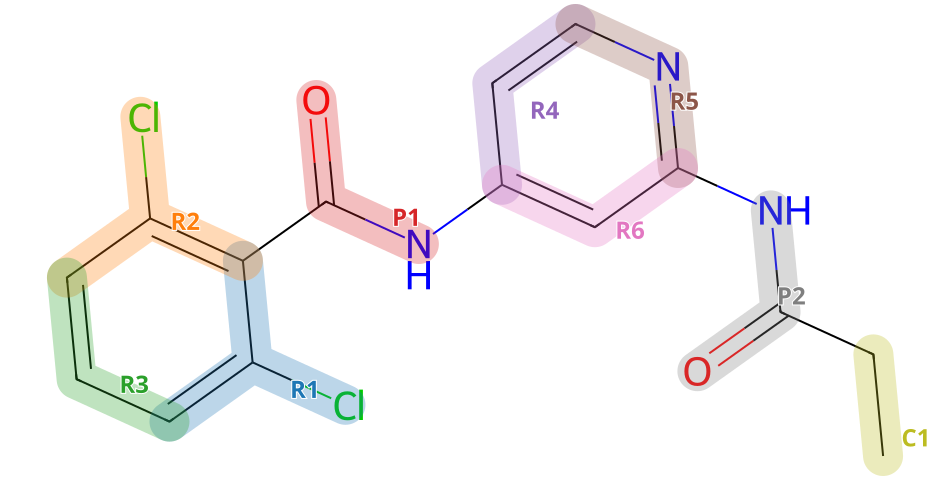

In [4]:
shaker.render.render_2dMapping(GRO, resname, bead_assignments, bead_names,conn_r=20.0,font_size=24)
display(SVG("cg_overlay.svg"))

In [5]:
shaker.render.render_mapping('./cg_mapped.gro', './cg_mapped.xtc',
                           GRO, XTC, size='500px')

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:240: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


NGLWidget(frame=True, max_frame=2500)

### 2. Initial SASA calculations (AA vs mapped-CG)

A key step in Martini parameterization is ensuring that the **CG representation preserves the overall molecular shape** of the AA molecule. This is typically evaluated by comparing the **SASA (solvent accessible surface area)** and **Connolly surface** between the AA structure and the CG-mapped model.

Ideally, the **AA and CG-mapped SASA values should differ by less than ~5%** (differences up to ~10% are generally still acceptable). Larger deviations may indicate that the mapping does not accurately capture the molecule’s shape or volume, in which case the mapping should be revisited.

SASA can be calculated using `shaker.sasa.run_SASA`, which runs `gmx sasa` in the background. The resulting distributions can then be visualized using `shaker.plot.plot_sasa_dir()`.

It is important to note that **matching the molecular shape**, as reflected by the **Connolly surface**, is often as important—or even more important—than matching the SASA percentage itself. SASA values can be influenced by factors such as overall molecular size or slight differences in bead placement.

The Connolly surface can be visualized using `shaker.render.render_connely_surface`, which helps confirm that the CG mapping reproduces the overall geometry of the atomistic molecule.


/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/GRO.py:479: UserWarning: missing dimension - setting unit cell to zeroed box [0., 0., 0.]
  warnings.warn(wmsg)
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


CG_mapped model is 92.28% of AA.


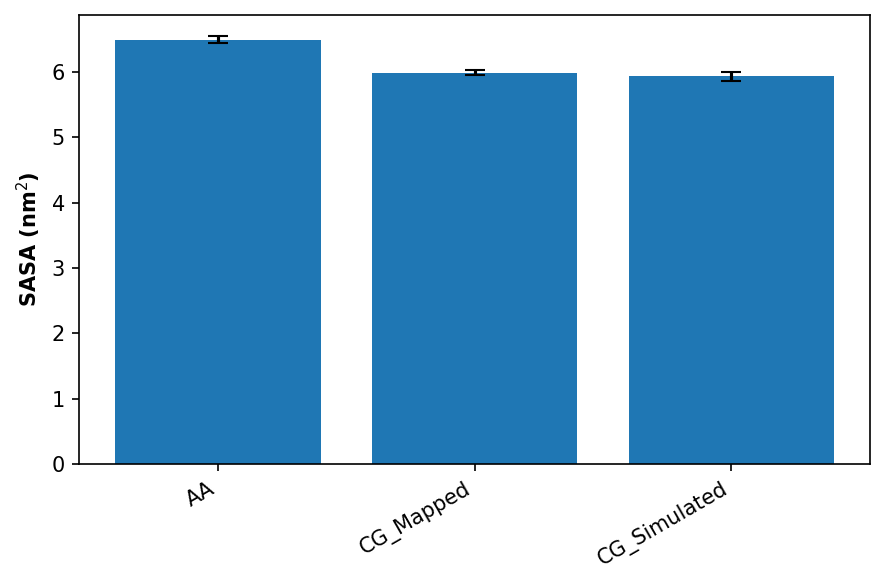

In [6]:
shaker.sasa.run_SASA('CG_Mapped',
                     f'{main_dir}/cg_mapped.gro', f'{main_dir}/cg_mapped.xtc', resname, 
                     bead_names=bead_names, bead_types=bead_types, isCG=True)
shaker.sasa.run_SASA('AA', GRO, XTC,resname)

fig, ax, sasa_values = shaker.plot.plot_sasa_dir()

CG_over_AA_ratio = sasa_values[1][1] / sasa_values[0][1]
print(f"CG_mapped model is {CG_over_AA_ratio:.2%} of AA.")

In [7]:
shaker.render.render_connely_surface(size='500px')

no trajectory available


NGLWidget(frame=True)

### 3. Obtain initial bonded parameter guesses

This is still a work in progress.

### 4. Prepare and run a simple CG system

At this stage we prepare a short **CG simulation of our molecule in water**, which will be used to calculate bonded distributions and compare them against the **AA/QM reference**.

`shaker.itp.write_initial_CGitp` generates a basic topology file, `initial_CG.itp`, containing the bead definitions based on the mapping defined earlier. The file can also be populated with the **initial bonded parameter guesses** obtained in the previous step.

When starting the optimization, it is generally best to begin with a **simple bonded model** and progressively increase complexity. A typical strategy is to introduce bonded terms in stages:

`bonds / constraints → angles → dihedrals → higher-order terms`

This makes it easier to identify which interactions influence specific structural features of the molecule.

To run the CG simulation, `shaker.system_builders.prepare_setup_water` prepares a simple system containing `n_mols` copies of the molecule solvated in water. The simulation can then be launched using `shaker.system_builders.runSim`.

`Shaker` is distributed with **up-to-date Martini 3 topology files and `.mdp` parameters** suitable for parameterization workflows, allowing simulations to be set up and run with minimal manual configuration.


In [8]:
dir_run=f'{main_dir}/CG_WAT'
try:    
    os.mkdir(dir_run)
except FileExistsError:
    pass
os.chdir(dir_run)

if not os.path.exists('initial_CG.itp'):
    shaker.itp.write_initial_CGitp(resname,
                                   bead_names,
                                   bead_types,
                                   bead_charges,
                                   header = ''.join(itp_header))
os.chdir(main_dir)

In [9]:
## Set up the initial system.
## Simple box of water with the molecule of interest.
os.chdir(dir_run)
shaker.system_builders.prepare_setup_water('../cg_mapped.gro', n_mols=1)
shaker.system_builders.runSim(maxwarn=2)
os.chdir(main_dir)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/coordinates/GRO.py:228: UserWarning: Empty box [0., 0., 0.] found - treating as missing unit cell. Dimensions set to `None`.
  warnings.warn(wmsg)
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


                      :-) GROMACS - gmx grompp, 2023.5 (-:

Executable:   /DAMM/software/gromacs/trixie/AVX2_256/gromacs-2023.5/bin/gmx
Data prefix:  /DAMM/software/gromacs/trixie/AVX2_256/gromacs-2023.5
Working dir:  /local/lborge01/shaker_tests/SimpleParameterization/CG_WAT
Command line:
  gmx grompp -f /local/lborge01/gitbuilds/Shaker/shaker/data/mdps/min.mdp -c memion_2.gro -p topol.top -o m.tpr -maxwarn 2

Ignoring obsolete mdp entry 'ns_type'

WARNING 1 [file topol.top, line 12]:
  The following macros were defined in the 'define' mdp field with the -D
  prefix, but were not used in the topology:
      FLEXIBLE
  If you haven't made a spelling error, either use the macro you defined,
  or don't define the macro

Number of degrees of freedom in T-Coupling group rest is 1905.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

There was 1 WARNING

GROMACS reminds you: "I Don't Want to Calm Down" (Throwing Muses)

Setting the LD random 

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


### 5. Bonded parameter optimization

After running the initial CG simulation, the next step is to **refine the bonded parameters** so that the CG model reproduces the conformational behavior observed in the reference data.

Bonded distributions for both the **CG simulation** and the chosen **reference trajectory (AA or QM-derived)** can be calculated using `shaker.measurer.measure_bonded_terms`. This function takes as input three lists defining the **distances**, **angles**, and **dihedrals** that should be measured.

It is important to monitor **all bonded degrees of freedom relevant to the molecule’s dynamics**, even if you do not plan to explicitly apply a potential to each one. Tracking these distributions ensures that changes in one bonded term do not unintentionally distort other parts of the molecule.

The resulting distributions can be visualized using `shaker.plot.plot_bonded_distributions`, which allows direct comparison between the CG simulation and the reference data.

To see how the final parameterized molecule behaves, an example of a **fully optimized `.itp` file** is provided in `AA_references/BasicParam`.


In [9]:
ang_tgts =  [
    ['C1', 'P2', 'R5'],
    ['R1', 'R2', 'R4'],
    ['R2', 'R4', 'R6'],
    ['R1', 'R2', 'P1'],
    ['R2', 'P1', 'R4'],
    ['R2', 'P1', 'R4'],
    ['P1', 'R4', 'R6'],
    ['R2', 'P1', 'R4'],
    ['R2', 'P1', 'R6'],
    ['R1', 'P1', 'R4'],
    ['R1', 'P1', 'R6'],
    ['P1', 'R4', 'R6'],
    ['R3', 'P1', 'R5'],
    ['R3', 'R1', 'P1'],
]

dist_tgts =[
            ['R1', 'R2'],
            ['R1', 'R3'],
            ['R2', 'R3'],
            ['R4', 'R5'],
            ['R4', 'R6'],
            ['R5', 'R6'],
            ['R1', 'P1'],
            ['R2', 'P1'],
            ['P1', 'R4'],
            ['P1', 'R6'],
            ['R5', 'P2'],
            ['R6', 'P2'],
            ['P2', 'C1'],
           ]       

dihed_tgts =[
          ['R1', 'R2', 'R4', 'R6'],
          ['R3', 'R1', 'R2', 'P1'],
          ['R5', 'R4', 'R6', 'P1'],
          ['R4', 'R6', 'R5', 'P2'],
          ['C1', 'P2', 'R5', 'R6'],
          ['R3', 'R2', 'P1', 'R4'],
          ['R3', 'R1', 'P1', 'R4'],
          ['R3', 'R2', 'P1', 'R6'],
          ['R1', 'R2', 'P1', 'R4'],
          ['R2', 'P1', 'R4', 'R6'],
          ['R2', 'P1', 'R4', 'R6'],
           ]  

In [10]:
u_aa = md.Universe(f'{main_dir}/cg_mapped.gro',
                   f'{main_dir}/cg_mapped.xtc')
AA_bonded = shaker.measurer.measure_bonded_terms(u_aa, resname, 
                                                 dist_tgts, ang_tgts, dihed_tgts,
                                                 stride=1)

u_cg = md.Universe(f'{main_dir}/CG_WAT/pbc.pdb',
                   f'{main_dir}/CG_WAT/pbc.xtc')
CG_bonded = shaker.measurer.measure_bonded_terms(u_cg, resname, 
                                                 dist_tgts, ang_tgts, dihed_tgts,
                                                 stride=1)

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
100%|█████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.34s/it]
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
100%|█████████████████████████████████████████████████████| 1/1 [00:06<00:00,  6.27s/it]


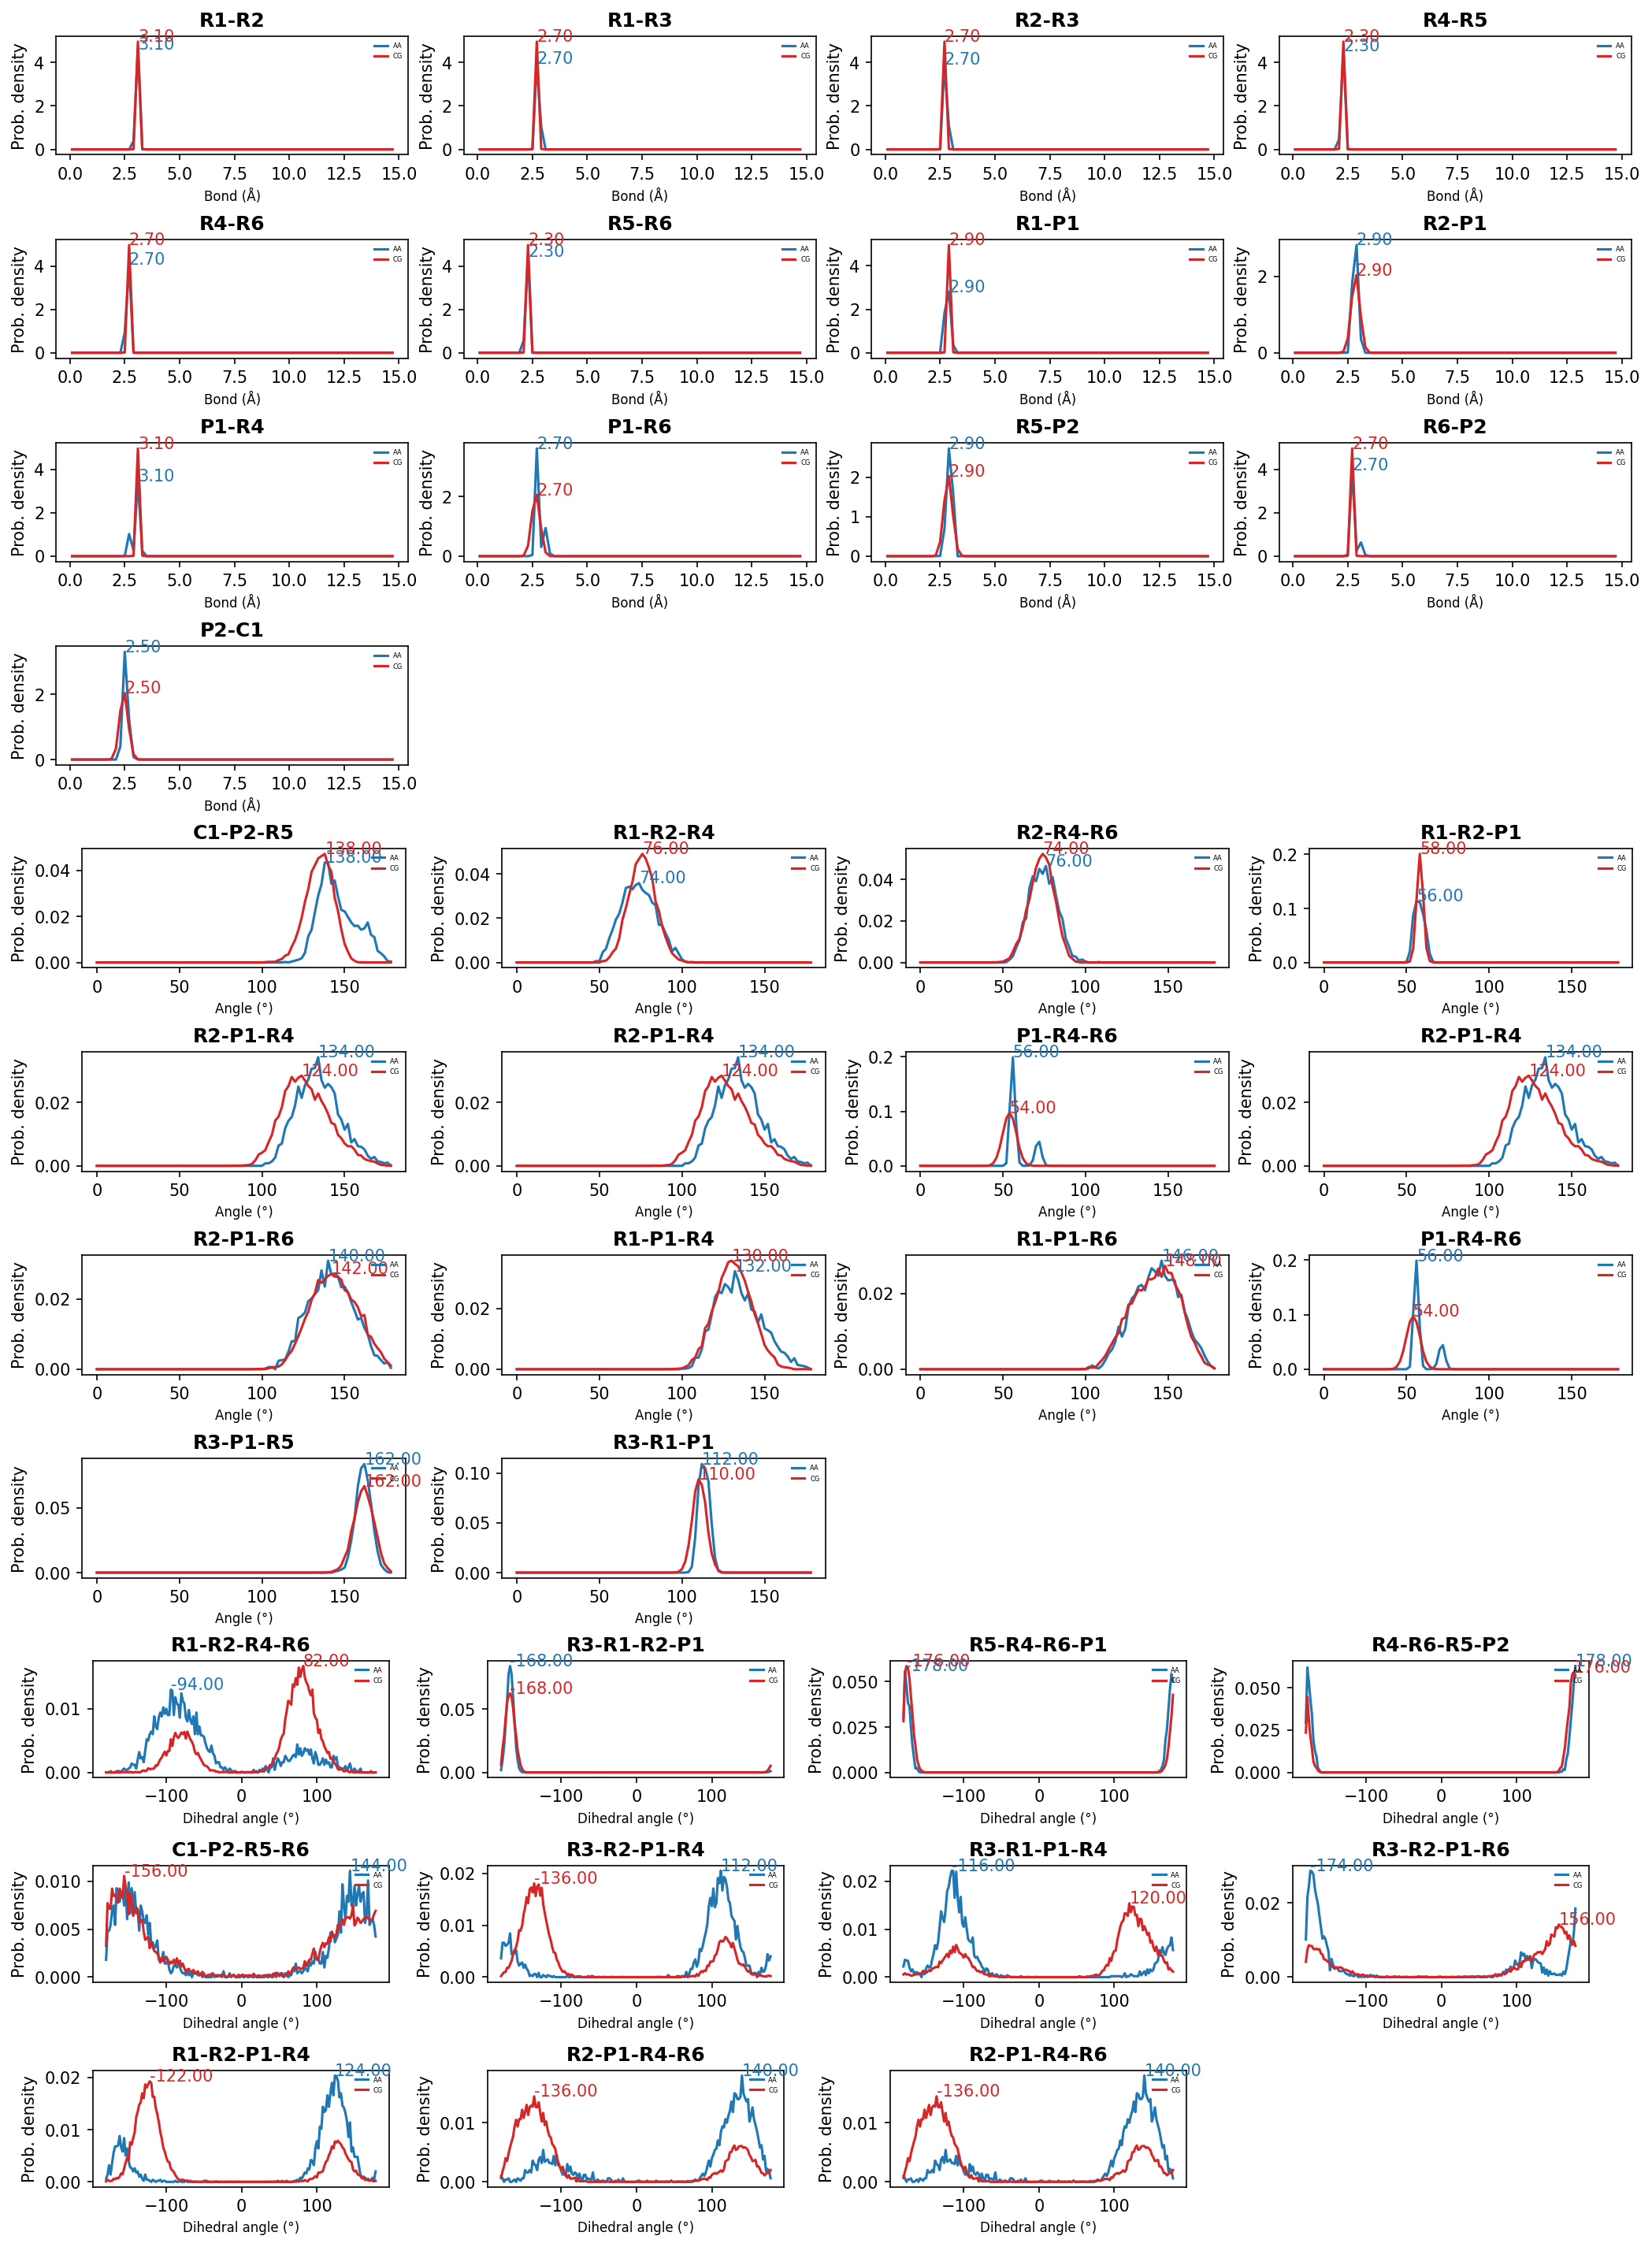

In [11]:
fig = shaker.plot.plot_bonded_distributions(
            AA_bonded,
            CG_bonded,
            labels=["AA", "CG"],
            colors=["tab:blue", "tab:red"],
            outfile="cleanbonds")

#### 5.1. Recalculate SASA

It is also useful to routinely check the **SASA** of the CG simulated molecule during the optimization process. Changes to bonded parameters can alter the molecule’s average compactness and solvent exposure, which will be reflected in its SASA.

This can again be calculated using `shaker.sasa.run_SASA` and visualized with `shaker.plot.plot_sasa_dir`.

If the bonded parameters are defined correctly, the **CG simulated SASA** should closely match both the **CG-mapped trajectory** and the **AA reference**. Significant deviations may indicate that further refinement of the bonded parameters may still be required.


/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


CG_Simulated model is 91.40% of AA.


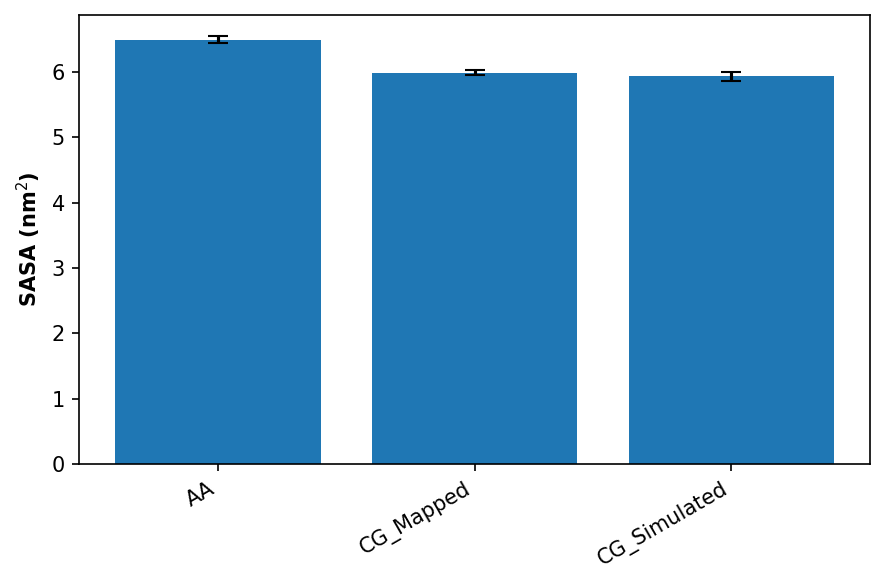

In [12]:
os.chdir(main_dir)
shaker.sasa.run_SASA('CG_Simulated',
                     f'{main_dir}/CG_WAT/pbc.pdb', f'{main_dir}/CG_WAT/pbc.xtc', resname, 
                     bead_names=bead_names, bead_types=bead_types, isCG=True)
fig, ax, sasa_values = shaker.plot.plot_sasa_dir()

CG_over_AA_ratio = sasa_values[2][1] / sasa_values[0][1]
print(f"CG_Simulated model is {CG_over_AA_ratio:.2%} of AA.")

#### 5.2. Analyze molecule ensemble dynamics

Even after carefully optimizing bonded parameters, it is common to assume the parametrization is complete while some bonded terms remain incorrect. Small issues in angles or dihedrals may not be immediately obvious when inspecting individual distributions, but they can significantly affect the molecule’s overall conformational behavior. For this reason, it is often useful to evaluate the **ensemble of conformations** sampled during the simulation rather than focusing only on individual bonded terms.

A simple way to do this is to visualize many frames from the trajectory at once. This allows us to qualitatively assess the **range of conformations**, **flexibility**, and **accessible degrees of freedom** of the molecule.

`shaker.render.render_ensemble` provides a convenient way to do this. The function centers and aligns the molecule of interest and renders `n_frames` sampled from the trajectory for both the **CG-mapped atomistic trajectory** and the **CG simulation trajectory**.

By comparing these two ensembles, we can quickly determine whether the CG model reproduces the conformational space observed in the mapped atomistic reference. If the bonded parameters are well parameterized, both ensembles should display **similar structural variability, flexibility, and overall conformational distributions**. Significant differences—such as overly restricted motion or unrealistic conformations—indicate that some bonded parameters may still require refinement.


In [13]:
## AA
shaker.render.render_ensemble('./CG_WAT/pbc.pdb', './cg_mapped.xtc',
                                sel="name P1 R4 R5 R6 P2",
                                n_frames=100
                                , size="400px")

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


NGLWidget()

In [14]:
## CG
shaker.render.render_ensemble('./CG_WAT/pbc.pdb', './CG_WAT/pbc.xtc',
                                sel="name P1 R4 R5 R6 P2",
                                n_frames=100
                                , size="400px")

/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
/local/lborge01/miniconda3/envs/general_env/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: R
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


NGLWidget()